# v1 anomaly pipeline — train on normal, detect on unseen faults

Protocol:

1. **Load all healthy rows** (`faultNumber == 0`, every source/run). That is ~730k rows and fits in RAM.
2. **Split those normal runs 70 / 15 / 15 by (`source`, `simulationRun`)** (shuffle run IDs, never cut a trajectory):
   - 70% train — fit PCA, μ, σ
   - 15% validation — choose anomaly thresholds
   - 15% test — final false-alarm check
3. **Score every faulty row** (`faultNumber > 0`) from the CSV **in batches**. Do not keep the 14.6M fault rows in RAM.

`te_process.csv` is the Rieth Tennessee Eastman set. The CSV column is `faultNumber` (not `fault_id`). `fault_status` is a **run-level** tag and is wrong as a sample label: test IDV(k) rows 1–160 are still healthy. Labels are rebuilt from `sample`.


In [10]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

CSV_PATH = Path("te_process.csv")
META_COLS = ["faultNumber", "simulationRun", "sample", "source", "fault_status"]

# Stream size for (1) loading all IDV(0) and (2) scoring all faults without holding them.
CHUNKSIZE = 250_000

# Normal-only split by shuffled (source, simulationRun). Not timestamps.
TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15
SPLIT_SEED = 42

TRAIN_FAULT_SAMPLE = 21   # Rieth train files: disturbance at 1 h
TEST_FAULT_SAMPLE = 161   # Rieth test files: disturbance at 8 h
SAMPLE_MINUTES = 3

print("config")
print(f"  csv            {CSV_PATH.resolve()}")
print("  train          all faultNumber=0 rows (~730k, kept in RAM)")
print("  test faults    all faultNumber>0 rows, scored in chunks (not kept in RAM)")
print(f"  chunksize      {CHUNKSIZE:,}")
print(f"  normal_split   {TRAIN_FRAC:.0%} train / {VAL_FRAC:.0%} val / {TEST_FRAC:.0%} test  (by run, seed={SPLIT_SEED})")


config
  csv            /Users/ob/Projects/hackathon_csv/data_processing/te_process.csv
  train          all faultNumber=0 rows (~730k, kept in RAM)
  test faults    all faultNumber>0 rows, scored in chunks (not kept in RAM)
  chunksize      250,000
  normal_split   70% train / 15% val / 15% test  (by run, seed=42)


## 1. Load trajectories

Stream the CSV once and keep **every** `faultNumber == 0` row (train + test files). Faulty rows are skipped here and scored later in batches. Compact dtypes so the healthy table stays small.


In [ ]:
def sensor_columns(columns) -> list[str]:
    return [c for c in columns if c.startswith("xmeas_") or c.startswith("xmv_")]


def compact_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["faultNumber"] = out["faultNumber"].astype(np.int16)
    out["simulationRun"] = out["simulationRun"].astype(np.int16)
    out["sample"] = out["sample"].astype(np.int16)
    out["source"] = out["source"].astype("category")
    if "fault_status" in out.columns:
        out["fault_status"] = out["fault_status"].astype("category")
    for c in sensor_columns(out.columns):
        out[c] = pd.to_numeric(out[c], downcast="float")
    return out


def iter_csv_chunks(path: Path = CSV_PATH, usecols=None):
    header = pd.read_csv(path, nrows=0)
    cols = list(header.columns) if usecols is None else usecols
    yield from pd.read_csv(path, usecols=cols, chunksize=CHUNKSIZE)


def fault_onset(source: str | pd.Series) -> np.ndarray | int:
    if isinstance(source, str):
        return TEST_FAULT_SAMPLE if source == "test" else TRAIN_FAULT_SAMPLE
    return np.where(np.asarray(source) == "test", TEST_FAULT_SAMPLE, TRAIN_FAULT_SAMPLE)


def add_true_label(df: pd.DataFrame) -> pd.DataFrame:
    """Sample-level label. Do not use CSV `fault_status`."""
    out = df.copy()
    onset = fault_onset(out["source"])
    out["y_true"] = ((out["faultNumber"].astype(int) > 0) & (out["sample"].astype(int) >= onset)).astype(np.int8)
    return out


def load_all_normal(path: Path = CSV_PATH) -> pd.DataFrame:
    """Keep every IDV(0) row. Skip faults — those are scored later from disk."""
    header = pd.read_csv(path, nrows=0)
    features = sensor_columns(header.columns)
    usecols = META_COLS + features
    parts: list[pd.DataFrame] = []
    n_keep = 0
    n_seen = 0

    for i, chunk in enumerate(iter_csv_chunks(path, usecols=usecols), start=1):
        n_seen += len(chunk)
        taken = chunk.loc[chunk["faultNumber"].astype(int).eq(0)]
        if taken.empty:
            if i == 1 or i % 8 == 0:
                print(f"  chunk {i:3d}  scanned={n_seen:,}  kept={n_keep:,}")
            continue
        parts.append(compact_frame(taken))
        n_keep += len(taken)
        if i == 1 or i % 8 == 0:
            print(f"  chunk {i:3d}  scanned={n_seen:,}  kept={n_keep:,}")

    if not parts:
        raise RuntimeError(f"no IDV(0) rows in {path}")

    print(f"  done        scanned={n_seen:,}  kept={n_keep:,}")
    out = pd.concat(parts, ignore_index=True)
    return out.sort_values(
        ["source", "simulationRun", "sample"],
        kind="mergesort",
    ).reset_index(drop=True)


df_normal = add_true_label(load_all_normal())
FEATURE_COLS = sensor_columns(df_normal.columns)

print("\nloaded (healthy only)")
print("normal   ", df_normal.shape, "  faultNumber=0")
print(df_normal.groupby(["source", "faultNumber"], sort=True, observed=True).agg(
    n=("sample", "size"),
    runs=("simulationRun", "nunique"),
    smin=("sample", "min"),
    smax=("sample", "max"),
))
print(f"\nrows={len(df_normal):,}  sensors={len(FEATURE_COLS)}")
print("faulty rows are not in RAM; they will be scored in chunks after the fit.")

# df_normal consist of 480k test and 250k train rows


  chunk   1  scanned=250,000  kept=250,000
  chunk   8  scanned=2,000,000  kept=250,000
  chunk  16  scanned=4,000,000  kept=250,000
  chunk  24  scanned=6,000,000  kept=730,000
  chunk  32  scanned=8,000,000  kept=730,000
  chunk  40  scanned=10,000,000  kept=730,000
  chunk  48  scanned=12,000,000  kept=730,000
  chunk  56  scanned=14,000,000  kept=730,000
  done        scanned=15,330,000  kept=730,000

loaded (healthy only)
normal    (730000, 58)   faultNumber=0
                         n  runs  smin  smax
source faultNumber                          
test   0            480000   500     1   960
train  0            250000   500     1   500

rows=730,000  sensors=52
faulty rows are not in RAM; they will be scored in chunks after the fit.


## 2. Train / val / test

`df_normal` is **every** `faultNumber == 0` row. Shuffle `(source, simulationRun)` pairs (seeded), then assign whole trajectories:

- 70% → `train_normal` (fit PCA, μ, σ)
- 15% → `val_normal` (choose thresholds)
- 15% → `test_normal` (final false-alarm test)

Timestamps inside a run stay together. Faulty rows are not in this split; they are scored from disk in section 3.


In [13]:
def _run_keys(df: pd.DataFrame) -> pd.DataFrame:
    return df[["source", "simulationRun"]].drop_duplicates().reset_index(drop=True)


def _run_span(df: pd.DataFrame) -> str:
    keys = _run_keys(df)
    if keys.empty:
        return "runs=[]"
    return (
        f"trajectories={len(keys)}  "
        f"sources={sorted(keys['source'].astype(str).unique())}  "
        f"simRun=[{int(keys.simulationRun.min())}..{int(keys.simulationRun.max())}]"
    )


def split_normal_runs(
    normal: pd.DataFrame,
    train_frac: float = TRAIN_FRAC,
    val_frac: float = VAL_FRAC,
    seed: int = SPLIT_SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Assign whole (source, simulationRun) trajectories. Remainder goes to FAR-test."""
    keys = _run_keys(normal)
    rng = np.random.default_rng(seed)
    keys = keys.iloc[rng.permutation(len(keys))].reset_index(drop=True)
    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_keys = keys.iloc[:n_train]
    val_keys = keys.iloc[n_train:n_train + n_val]
    test_keys = keys.iloc[n_train + n_val:]

    train_df = normal.merge(train_keys, on=["source", "simulationRun"], how="inner")
    val_df = normal.merge(val_keys, on=["source", "simulationRun"], how="inner")
    test_df = normal.merge(test_keys, on=["source", "simulationRun"], how="inner")
    return train_df, val_df, test_df, train_keys, val_keys, test_keys


train_normal, val_normal, test_normal, train_keys, val_keys, test_keys = split_normal_runs(df_normal)

print("split  (healthy trajectories shuffled, then 70/15/15)")
print("  df_normal    ", df_normal.shape, " ", _run_span(df_normal))
print("  train_normal ", train_normal.shape, " ", _run_span(train_normal), f"  assigned={len(train_keys)}")
print("  val_normal   ", val_normal.shape, " ", _run_span(val_normal), f"  assigned={len(val_keys)}")
print("  test_normal  ", test_normal.shape, " ", _run_span(test_normal), f"  assigned={len(test_keys)}")
print("  faulty        not loaded  (scored later in batches)")


split  (healthy trajectories shuffled, then 70/15/15)
  df_normal     (730000, 58)   trajectories=1000  sources=['test', 'train']  simRun=[1..500]
  train_normal  (509160, 58)   trajectories=700  sources=['test', 'train']  simRun=[1..499]   assigned=700
  val_normal    (114560, 58)   trajectories=150  sources=['test', 'train']  simRun=[5..500]   assigned=150
  test_normal   (106280, 58)   trajectories=150  sources=['test', 'train']  simRun=[1..492]   assigned=150
  faulty        not loaded  (scored later in batches)


In [14]:
def overlap(a: pd.DataFrame, b: pd.DataFrame, cols=("source", "faultNumber", "simulationRun", "sample")) -> int:
    if a.empty or b.empty:
        return 0
    return int(pd.merge(a[list(cols)], b[list(cols)], how="inner").shape[0])


def _keyset(keys: pd.DataFrame) -> set[tuple]:
    return set(zip(keys["source"].astype(str), keys["simulationRun"].astype(int)))


train_set, val_set, far_set = _keyset(train_keys), _keyset(val_keys), _keyset(test_keys)
frac_ok = abs(TRAIN_FRAC + VAL_FRAC + TEST_FRAC - 1.0) < 1e-9

checks = {
    "train contains only faultNumber=0": train_normal["faultNumber"].eq(0).all(),
    "val contains only faultNumber=0": val_normal["faultNumber"].eq(0).all(),
    "FAR-test contains only faultNumber=0": test_normal["faultNumber"].eq(0).all(),
    "train y_true is all 0": train_normal["y_true"].eq(0).all(),
    "val y_true is all 0": val_normal["y_true"].eq(0).all(),
    "FAR-test y_true is all 0": test_normal["y_true"].eq(0).all(),
    "no row overlap train/val": overlap(train_normal, val_normal) == 0,
    "no row overlap train/FAR-test": overlap(train_normal, test_normal) == 0,
    "no row overlap val/FAR-test": overlap(val_normal, test_normal) == 0,
    "no shared trajectory train/val": train_set.isdisjoint(val_set),
    "no shared trajectory train/FAR-test": train_set.isdisjoint(far_set),
    "no shared trajectory val/FAR-test": val_set.isdisjoint(far_set),
    "every normal trajectory assigned once": train_set | val_set | far_set == _keyset(_run_keys(df_normal)),
    "split fractions sum to 1": frac_ok,
}

print("sanity")
for name, ok in checks.items():
    print(f"  [{'ok' if ok else 'FAIL'}] {name}")
if not all(checks.values()):
    raise AssertionError("split sanity checks failed")

print("\nshapes")
print("  train_normal", train_normal.shape)
print("  val_normal  ", val_normal.shape)
print("  test_normal ", test_normal.shape)

print("\nlabel counts")
print("  train_normal  y_true", train_normal["y_true"].value_counts().to_dict())
print("  val_normal    y_true", val_normal["y_true"].value_counts().to_dict())
print("  test_normal   y_true", test_normal["y_true"].value_counts().to_dict())


sanity
  [ok] train contains only faultNumber=0
  [ok] val contains only faultNumber=0
  [ok] FAR-test contains only faultNumber=0
  [ok] train y_true is all 0
  [ok] val y_true is all 0
  [ok] FAR-test y_true is all 0
  [ok] no row overlap train/val
  [ok] no row overlap train/FAR-test
  [ok] no row overlap val/FAR-test
  [ok] no shared trajectory train/val
  [ok] no shared trajectory train/FAR-test
  [ok] no shared trajectory val/FAR-test
  [ok] every normal trajectory assigned once
  [ok] split fractions sum to 1

shapes
  train_normal (509160, 58)
  val_normal   (114560, 58)
  test_normal  (106280, 58)

label counts
  train_normal  y_true {0: 509160}
  val_normal    y_true {0: 114560}
  test_normal   y_true {0: 106280}


## 3. Baseline detector (PCA-SPE)

Fit a PCA envelope on **train_normal only**. The SPE threshold is the 99th percentile of training residuals. Validation and healthy-test FAR should stay near 1%. Then stream every `faultNumber > 0` row from the CSV in chunks and accumulate detection stats — the fault table never sits in RAM.


In [15]:
class PcaSpeDetector:
    """Unsupervised SPE detector. Fit exclusively on normal samples."""

    def __init__(self, variance=0.90, spe_quantile=0.99):
        self.variance = variance
        self.spe_quantile = spe_quantile
        self.mu_ = None
        self.sd_ = None
        self.P_ = None
        
        self.n_comp_ = None
        self.limit_ = None

    def fit(self, frame: pd.DataFrame, cols=None):
        cols = cols or FEATURE_COLS
        X = frame[cols].to_numpy(dtype=np.float64)
        self.mu_ = X.mean(axis=0)
        sd = X.std(axis=0)
        sd[sd == 0] = 1.0
        self.sd_ = sd
        Z = (X - self.mu_) / self.sd_
        _, S, Vt = np.linalg.svd(Z, full_matrices=False)
        explained = np.cumsum(S**2) / (S**2).sum()
        self.n_comp_ = int(np.searchsorted(explained, self.variance) + 1)
        self.P_ = Vt[: self.n_comp_].T
        spe = ((Z - Z @ self.P_ @ self.P_.T) ** 2).sum(axis=1)
        self.limit_ = float(np.quantile(spe, self.spe_quantile))
        return self

    def score(self, frame: pd.DataFrame, cols=None) -> pd.DataFrame:
        cols = cols or FEATURE_COLS
        Z = (frame[cols].to_numpy(dtype=np.float64) - self.mu_) / self.sd_
        spe = ((Z - Z @ self.P_ @ self.P_.T) ** 2).sum(axis=1)
        out = frame[META_COLS + ["y_true"]].copy()
        out["spe"] = spe
        out["alarm"] = spe > self.limit_
        return out


assert train_normal["faultNumber"].eq(0).all() and train_normal["y_true"].eq(0).all()

detector = PcaSpeDetector().fit(train_normal)
print(
    f"PCA-SPE  n_comp={detector.n_comp_}  "
    f"SPE {detector.spe_quantile:.0%} limit={detector.limit_:.2f}"
)

val_scores = detector.score(val_normal)
far_val = float(val_scores["alarm"].mean())
print(f"val FAR (should be ~{1 - detector.spe_quantile:.0%} if val matches train): {far_val:.3f}")

if not test_normal.empty:
    far_test_healthy = float(detector.score(test_normal)["alarm"].mean())
    print(f"test IDV(0) FAR: {far_test_healthy:.3f}")


PCA-SPE  n_comp=31  SPE 99% limit=11.72
val FAR (should be ~1% if val matches train): 0.010
test IDV(0) FAR: 0.010


In [16]:
def iter_fault_chunks(path: Path = CSV_PATH):
    header = pd.read_csv(path, nrows=0)
    usecols = META_COLS + sensor_columns(header.columns)
    n_seen = 0
    n_scored = 0
    for i, chunk in enumerate(iter_csv_chunks(path, usecols=usecols), start=1):
        n_seen += len(chunk)
        taken = chunk.loc[chunk["faultNumber"].astype(int).gt(0)]
        if taken.empty:
            if i == 1 or i % 8 == 0:
                print(f"  chunk {i:3d}  scanned={n_seen:,}  scored={n_scored:,}")
            continue
        n_scored += len(taken)
        if i == 1 or i % 8 == 0:
            print(f"  chunk {i:3d}  scanned={n_seen:,}  scored={n_scored:,}")
        yield add_true_label(compact_frame(taken))
    print(f"  done        scanned={n_seen:,}  scored={n_scored:,}")


def update_run_alarms(state: dict, scores: pd.DataFrame) -> None:
    """Keep the first post-onset alarm sample per (source, fault, run)."""
    post = scores.loc[scores["y_true"].eq(1) & scores["alarm"]]
    if post.empty:
        return
    first = (
        post.groupby(["source", "faultNumber", "simulationRun"], observed=True, sort=False)["sample"]
        .min()
    )
    for (src, fault, run), sample in first.items():
        key = (str(src), int(fault), int(run))
        prev = state.get(key)
        if prev is None or int(sample) < prev:
            state[key] = int(sample)


EXAMPLE_KEY = ("test", 1, 1)  # one trajectory for the plot; 960 rows max
example_parts: list[pd.DataFrame] = []
totals = {"n_pre": 0, "n_pre_alarm": 0, "n_post": 0, "n_post_alarm": 0}
by_idv = defaultdict(lambda: {"n_pre": 0, "n_pre_alarm": 0, "n_post": 0, "n_post_alarm": 0, "runs": set()})
first_alarm: dict[tuple, int] = {}

print("scoring all faulty rows in batches")
for chunk in iter_fault_chunks():
    scores = detector.score(chunk)
    pre = scores["y_true"].eq(0)
    post = scores["y_true"].eq(1)
    totals["n_pre"] += int(pre.sum())
    totals["n_pre_alarm"] += int(scores.loc[pre, "alarm"].sum())
    totals["n_post"] += int(post.sum())
    totals["n_post_alarm"] += int(scores.loc[post, "alarm"].sum())
    update_run_alarms(first_alarm, scores)

    for (src, fault), g in scores.groupby(["source", "faultNumber"], observed=True, sort=False):
        rec = by_idv[(str(src), int(fault))]
        rec["n_pre"] += int(g["y_true"].eq(0).sum())
        rec["n_pre_alarm"] += int(g.loc[g["y_true"].eq(0), "alarm"].sum())
        rec["n_post"] += int(g["y_true"].eq(1).sum())
        rec["n_post_alarm"] += int(g.loc[g["y_true"].eq(1), "alarm"].sum())
        rec["runs"].update(zip([str(src)] * len(g), g["simulationRun"].astype(int)))

    if sum(len(p) for p in example_parts) < 960:
        hit = scores.loc[
            scores["source"].astype(str).eq(EXAMPLE_KEY[0])
            & scores["faultNumber"].astype(int).eq(EXAMPLE_KEY[1])
            & scores["simulationRun"].astype(int).eq(EXAMPLE_KEY[2])
        ]
        if not hit.empty:
            example_parts.append(hit)

far_pre = totals["n_pre_alarm"] / totals["n_pre"] if totals["n_pre"] else np.nan
fdr_post = totals["n_post_alarm"] / totals["n_post"] if totals["n_post"] else np.nan
print(f"all faulty rows  FAR (healthy prefix): {far_pre:.3f}")
print(f"all faulty rows  FDR (after onset):    {fdr_post:.3f}")
print("scored", totals)


def median_delay(src: str, fault: int) -> float:
    onset = fault_onset(src)
    delays = [
        (sample - onset) * SAMPLE_MINUTES
        for (s, f, _run), sample in first_alarm.items()
        if s == src and f == fault
    ]
    return float(np.median(delays)) if delays else np.nan


rows = []
for (src, fault), rec in sorted(by_idv.items()):
    rows.append(
        {
            "source": src,
            "faultNumber": fault,
            "runs": len({r for _, r in rec["runs"]}),
            "FAR_prefix": rec["n_pre_alarm"] / rec["n_pre"] if rec["n_pre"] else np.nan,
            "FDR_post": rec["n_post_alarm"] / rec["n_post"] if rec["n_post"] else np.nan,
            "median_delay_min": median_delay(src, fault),
        }
    )
by_fault = pd.DataFrame(rows).set_index(["source", "faultNumber"])
print("\ndetection by IDV (all faulty rows, batched)")
display(by_fault.round(3))

example = (
    pd.concat(example_parts, ignore_index=True)
    .drop_duplicates(["source", "faultNumber", "simulationRun", "sample"])
    .sort_values("sample")
    if example_parts
    else pd.DataFrame()
)
print("example trajectory", example.shape, EXAMPLE_KEY)


scoring all faulty rows in batches
  chunk   1  scanned=250,000  scored=0
  chunk   8  scanned=2,000,000  scored=1,750,000
  chunk  16  scanned=4,000,000  scored=3,750,000
  chunk  24  scanned=6,000,000  scored=5,270,000
  chunk  32  scanned=8,000,000  scored=7,270,000
  chunk  40  scanned=10,000,000  scored=9,270,000
  chunk  48  scanned=12,000,000  scored=11,270,000
  chunk  56  scanned=14,000,000  scored=13,270,000
  done        scanned=15,330,000  scored=14,600,000
all faulty rows  FAR (healthy prefix): 0.008
all faulty rows  FDR (after onset):    0.623
scored {'n_pre': 1800000, 'n_pre_alarm': 14740, 'n_post': 12800000, 'n_post_alarm': 7979049}

detection by IDV (all faulty rows, batched)


runs  FAR_prefix  FDR_post  median_delay_min
source faultNumber                                              
test   1             500       0.009     0.997               6.0
       2             500       0.009     0.981              36.0
       3             500       0.009     0.011             237.0
       4             500       0.009     0.999               3.0
       5             500       0.009     0.149               6.0
       6             500       0.009     1.000               0.0
       7             500       0.009     1.000               0.0
       8             500       0.009     0.913              48.0
       9             500       0.009     0.011             228.0
       10            500       0.009     0.324              90.0
       11            500       0.009     0.600              21.0
       12            500       0.009     0.946              24.0
       13            500       0.009     0.938              90.0
       14            500       0.009     0.917               3.0
       15            500       0.009     0.012             223.5
       16            500       0.009     0.247              54.0
       17            500       0.009     0.924              69.0
       18            500       0.009     0.937             106.5
       19            500       0.009     0.083              15.0
       20            500       0.009     0.534              99.0
train  1             500       0.005     0.996               6.0
       2             500       0.005     0.968              36.0
       3             500       0.005     0.011             222.0
       4             500       0.005     0.998               3.0
       5             500       0.005     0.226               6.0
       6             500       0.005     1.000               0.0
       7             500       0.005     1.000               0.0
       8             500       0.005     0.885              45.0
       9             500       0.005     0.011             234.0
       10            500       0.005     0.321              96.0
       11            500       0.005     0.592              24.0
       12            500       0.005     0.928              24.0
       13            500       0.005     0.905              96.0
       14            500       0.005     0.915               3.0
       15            500       0.005     0.011             220.5
       16            500       0.005     0.241              60.0
       17            500       0.005     0.893              87.0
       18            500       0.005     0.878             127.5
       19            500       0.005     0.081              18.0
       20            500       0.005     0.514             108.0

example trajectory (960, 8) ('test', 1, 1)


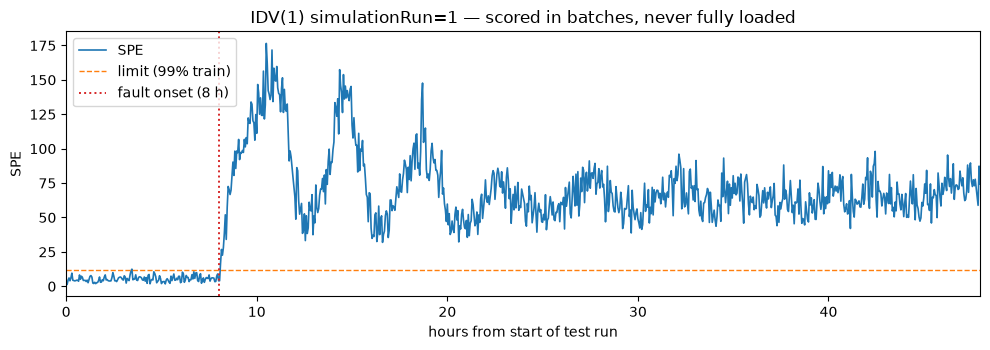

first post-onset alarm at sample 163  (6 min after onset)


In [17]:
# One held-out trajectory collected during the batch pass (test IDV(1) run 1).
if example.empty:
    raise RuntimeError(f"did not see {EXAMPLE_KEY} while scoring; cannot plot")

hours = (example["sample"] - 1) * SAMPLE_MINUTES / 60
onset_h = (TEST_FAULT_SAMPLE - 1) * SAMPLE_MINUTES / 60

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.plot(hours, example["spe"], lw=1.2, label="SPE")
ax.axhline(detector.limit_, color="C1", ls="--", lw=1, label=f"limit ({detector.spe_quantile:.0%} train)")
ax.axvline(onset_h, color="C3", ls=":", lw=1.4, label="fault onset (8 h)")
ax.set_xlabel("hours from start of test run")
ax.set_ylabel("SPE")
ax.set_title(f"IDV(1) simulationRun={int(example['simulationRun'].iloc[0])} — scored in batches, never fully loaded")
ax.legend(loc="upper left")
ax.set_xlim(0, float(hours.max()))
fig.tight_layout()
plt.show()

first_hit = example.loc[example["sample"].ge(TEST_FAULT_SAMPLE) & example["alarm"], "sample"]
if first_hit.empty:
    print("no alarm after onset on this run")
else:
    delay = (int(first_hit.iloc[0]) - TEST_FAULT_SAMPLE) * SAMPLE_MINUTES
    print(f"first post-onset alarm at sample {int(first_hit.iloc[0])}  ({delay} min after onset)")
